# 05 - Modeling and Evaluation

In this notebook, we will build, train, and evaluate a machine learning regression model to predict house sale prices.

## Objectives:

1. **Load the Data**: Import the engineered dataset prepared in the previous stage.
2. **Train/Test Split**: Divide the data into training and testing sets to evaluate model generalization.
3. **ML Pipeline Setup**: Create a robust Scikit-Learn pipeline for feature scaling and model training.
4. **Hyperparameter Optimization**: Use GridSearchCV to find the best settings for our Random Forest model.
5. **Model Evaluation**: Analyze model performance using R2 Score and Mean Absolute Error (MAE) in real dollars.
6. **Model Comparison**: Model Comparison: Compare the optimized Random Forest against baseline models (Linear Regression and Decision Tree) and conduct an architectural experiment on feature selection to justify the final model choice.
7. **Save the Trained Model**: Serialize the final pipeline and feature list for deployment in the Streamlit dashboard.
8. **Generate and Save Performance Plots**: Export static images of the model's evaluation plots and feature importance for the Streamlit dashboard.

**Dataset source:** `outputs/datasets/collection/house_prices_records_engineered.csv`

---
## 1. Load the Data

We will begin by loading the fully engineered dataset saved at the end of the Feature Engineering notebook. This dataset contains only numerical, scaled features, making it completely ready for the machine learning algorithms.

In [2]:
import pandas as pd

# Load Engineered dataset using the absolute path in the workspace
engineered_dataset_path = "../outputs/datasets/collection/house_prices_records_engineered.csv"
df = pd.read_csv(engineered_dataset_path)

# Verify successful loading by checking the dataframe dimensions
print(f"✅ Success! Dataset loaded with {df.shape[0]} rows and {df.shape[1]} columns.")
df.head(5)


✅ Success! Dataset loaded with 1460 rows and 22 columns.


,1stFlrSF,2ndFlrSF,BedroomAbvGr,BsmtExposure,BsmtFinSF1,BsmtFinType1,BsmtUnfSF,GarageArea,GarageFinish,GrLivArea,...,LotFrontage,MasVnrArea,OpenPorchSF,OverallCond,OverallQual,TotalBsmtSF,SalePrice,HouseAge,RemodelAge,GarageAge
0,-0.803645,1.241933,0.153895,-0.666314,0.779431,1.153467,-0.340511,0.351000,0.233235,0.529194,...,-0.078896,1.203619,0.845209,-0.517200,0.651479,0.002513,12.247699,-1.050994,-0.878668,-1.017598
1,0.418479,-0.824920,0.153895,2.028309,0.888257,0.666060,0.002218,-0.060731,0.233235,-0.381965,...,0.572719,-0.806841,-1.072916,2.179628,-0.071836,0.341114,12.109016,-0.156734,0.429577,0.107927
2,-0.576677,1.246200,0.153895,0.526075,0.654803,1.153467,0.230372,0.631726,0.233235,0.659631,...,0.062541,1.131524,0.675137,-0.517200,0.651479,0.065397,12.317171,-0.984752,-0.830215,-0.934226
3,-0.439421,-0.824920,0.153895,-0.666314,0.384539,0.666060,0.348034,0.790804,-0.993000,0.541448,...,-0.329561,-0.806841,0.592558,-0.517200,0.651479,-0.105819,11.849405,1.863632,0.720298,-0.809167
4,0.112127,-0.824920,1.416182,1.372089,0.754400,1.153467,0.295711,1.698485,0.233235,1.282295,...,0.726089,1.423411,0.991848,-0.517200,1.374795,0.256237,12.429220,-0.951632,-0.733308,-0.892540


### 1.1 Custom Functions for Model Evaluation

To maintain clean code and follow the DRY (Don't Repeat Yourself) principle, we define custom utility functions to evaluate our regression models. 

These functions automatically calculate key performance metrics ($R^2$, MAE, MSE, RMSE) and generate Actual vs. Predicted scatter plots. Crucially, they use `np.expm1()` to reverse the logarithmic transformation applied to the `SalePrice` during the Feature Engineering phase, ensuring all evaluations and charts are displayed in real US Dollars.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

def regression_performance(X_train, y_train, X_test, y_test, pipeline):
    """ Evaluates the model performance on both Train and Test sets """
    print("=== Model Evaluation ===\n")
    print("* Train Set")
    regression_evaluation(X_train, y_train, pipeline)
    print("* Test Set")
    regression_evaluation(X_test, y_test, pipeline)

def regression_evaluation(X, y, pipeline):
    """ Predicts and calculates metrics in real US Dollars """
    prediction = pipeline.predict(X)
    
    # Reverse the logarithm to evaluate in real US Dollars ($)
    y_real = np.expm1(y)
    prediction_real = np.expm1(prediction)
    
    print('R2 Score:', r2_score(y_real, prediction_real).round(3))
    print('Mean Absolute Error:', mean_absolute_error(y_real, prediction_real).round(3))
    print('Mean Squared Error:', mean_squared_error(y_real, prediction_real).round(3))
    print('Root Mean Squared Error:', np.sqrt(mean_squared_error(y_real, prediction_real)).round(3))
    print("\n")

def regression_evaluation_plots(X_train, y_train, X_test, y_test, pipeline, alpha_scatter=0.5):
    """ Generates Actual vs Prediction plots for Train and Test in real US Dollars """
    pred_train = pipeline.predict(X_train)
    pred_test = pipeline.predict(X_test)
    
    # Reverse the logarithm for the plots
    y_train_real = np.expm1(y_train)
    pred_train_real = np.expm1(pred_train)
    y_test_real = np.expm1(y_test)
    pred_test_real = np.expm1(pred_test)
    
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12,6))
    
    # Train Set Plot
    sns.scatterplot(x=y_train_real, y=pred_train_real, alpha=alpha_scatter, ax=axes[0])
    sns.lineplot(x=y_train_real, y=y_train_real, color='red', ax=axes[0])
    axes[0].set_xlabel("Actual SalePrice ($)")
    axes[0].set_ylabel("Predicted SalePrice ($)")
    axes[0].set_title("Train Set")
    
    # Test Set Plot
    sns.scatterplot(x=y_test_real, y=pred_test_real, alpha=alpha_scatter, ax=axes[1])
    sns.lineplot(x=y_test_real, y=y_test_real, color='red', ax=axes[1])
    axes[1].set_xlabel("Actual SalePrice ($)")
    axes[1].set_ylabel("Predicted SalePrice ($)")
    axes[1].set_title("Test Set")
    
    plt.show()

### 1.2 Data Cleaning Refinement
Before proceeding to model training, we perform a final verification of the dataset. Since the **Random Forest** algorithm does not support missing values (NaN), we handle the remaining nulls in features such as `GarageFinish`, `BsmtFinType1`, and `BsmtExposure`. 

By dropping these rows, we ensure a stable input for our pipeline and prevent mathematical errors during the optimization process.

In [4]:
# Check for any remaining null values
print("--- Null values before cleaning ---")
print(df.isnull().sum().sort_values(ascending=False).head(5))

# Drop rows with any NaN values
df = df.dropna()

# Final verification of the dataset shape
print("\nCleaning Complete...")
print("\n--- Null values after cleaning ---")
print(df.isnull().sum().sort_values(ascending=False).head(5))
print(f"New dataset shape: {df.shape}")

--- Null values before cleaning ---
GarageFinish    235
BsmtFinType1    145
BsmtExposure     38
1stFlrSF          0
MasVnrArea        0
dtype: int64

Cleaning Complete...

--- Null values after cleaning ---
1stFlrSF      0
2ndFlrSF      0
RemodelAge    0
HouseAge      0
SalePrice     0
dtype: int64
New dataset shape: (1106, 22)


---
## 2. Train/Test Split

Before building our predictive pipeline, we must split our dataset into a training set and a testing set. 

* The **training set** (80% of the data) is used to teach the algorithm the mathematical patterns between the features and the target variable (`SalePrice`).
* The **testing set** (the remaining 20%) is kept entirely hidden from the model during training. We use it later to evaluate how accurately the model predicts prices on new, unseen data, acting as our primary validation step.

In [5]:
from sklearn.model_selection import train_test_split

# 1. Separating the Features (X) and the Target (y)
X = df.drop(columns=['SalePrice']) # All columns except the target
y = df['SalePrice']                # Only the target column

# 2. Performing the Train/Test Split (80% Train / 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3. Verifying the results
print(f"✅ Train/Test Split completed successfully!")
print(f"Training Features Shape (X_train): {X_train.shape}")
print(f"Testing Features Shape (X_test): {X_test.shape}")

✅ Train/Test Split completed successfully!
Training Features Shape (X_train): (884, 21)
Testing Features Shape (X_test): (222, 21)


---
## 3. ML Pipeline Setup

We will define a Scikit-Learn Pipeline. While our data is already scaled, using a pipeline is an industry best practice. It encapsulates the model (e.g., RandomForestRegressor or GradientBoostingRegressor) and any final feature selection steps, ensuring that any future data passing through the model undergoes the exact same process in the correct order.

In [5]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor

# 1. Initialize the Machine Learning Pipeline
# Using RandomForestRegressor directly on scaled data without explicit feature selection
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestRegressor(random_state=101))
])

# 2. Display the pipeline structure
print("✅ ML Pipeline successfully initialized!")
pipeline

✅ ML Pipeline successfully initialized!


Pipeline(steps=[('scaler', StandardScaler()),
                ('model', RandomForestRegressor(random_state=101))])

## 4. Hyperparameter Optimization

To find the most accurate configuration for our model, we implement **Hyperparameter Optimization** using `GridSearchCV`. Instead of accepting default settings, we program an automated search across a defined "grid" of parameters.

### Why use GridSearchCV?

* **Exhaustive Search**: It tests hundreds of combinations of settings (trees, depth, leaf nodes) to find the mathematical "sweet spot" for house price prediction.
* **Cross-Validation (CV)**: It splits the training data into 5 folds, training on 4 and validating on 1 in each cycle. This ensures the model's accuracy is consistent and prevents overfitting.
* **Pipeline Integration**: By wrapping our `pipeline` inside the search, we ensure that feature selection and model training are performed correctly within each cross-validation fold, preventing data leakage.

In [6]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Define the hyperparameter search space for optimization
param_grid = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [None, 10, 20],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4],
    'model__max_features': [1.0, 'sqrt', 'log2'],
    'model__max_leaf_nodes': [None, 10, 50]
}

# Initialize GridSearchCV with 5-fold cross-validation
# n_jobs=-1 uses all CPU cores to speed up the hundreds of trainings
search = GridSearchCV(
    pipeline, 
    param_grid, 
    cv=5, 
    scoring='r2', 
    n_jobs=-1, 
    verbose=1
)

# Execute the exhaustive search on training data
search.fit(X_train, y_train)

# Display optimization results
print(f"Best R2 Score found: {search.best_score_}")
print("Optimal Hyperparameters:")
search.best_params_



Fitting 5 folds for each of 729 candidates, totalling 3645 fits


Best R2 Score found: 0.8575526150230101
Optimal Hyperparameters:


{'model__max_depth': 20,
 'model__max_features': 'sqrt',
 'model__max_leaf_nodes': None,
 'model__min_samples_leaf': 1,
 'model__min_samples_split': 2,
 'model__n_estimators': 100}

## 5. Model Evaluation

Once the optimal model is found, we will evaluate its performance. We will compare the model's predictions against the actual `SalePrice` values for both the Training set and the Test set.

**💡 Important Note on Target Transformation:**
During the Feature Engineering phase, the `SalePrice` variable was log-transformed to achieve a normal distribution and improve the algorithm's performance. To interpret our evaluation metrics in real-world financial terms (actual Dollars instead of Log-Dollars), we will apply the inverse transformation (`np.expm1`) to both the actual and predicted values before calculating the errors.

Key metrics for this regression task include:

* **R2 Score:** Indicates the proportion of the variance in the target variable that is predictable from the features.
* **Mean Absolute Error (MAE):** The average magnitude of the errors in a set of predictions, without considering their direction. *(Now represented in Real Dollars)*.
* **Root Mean Squared Error (RMSE):** The square root of the average of the squared errors, heavily penalizing large outliers. *(Now represented in Real Dollars)*.

--- Optimized Random Forest Performance ---
=== Model Evaluation ===

* Train Set
R2 Score: 0.975
Mean Absolute Error: 6650.619
Mean Squared Error: 147001104.449
Root Mean Squared Error: 12124.401


* Test Set
R2 Score: 0.839
Mean Absolute Error: 20007.565
Mean Squared Error: 1193579468.132
Root Mean Squared Error: 34548.219




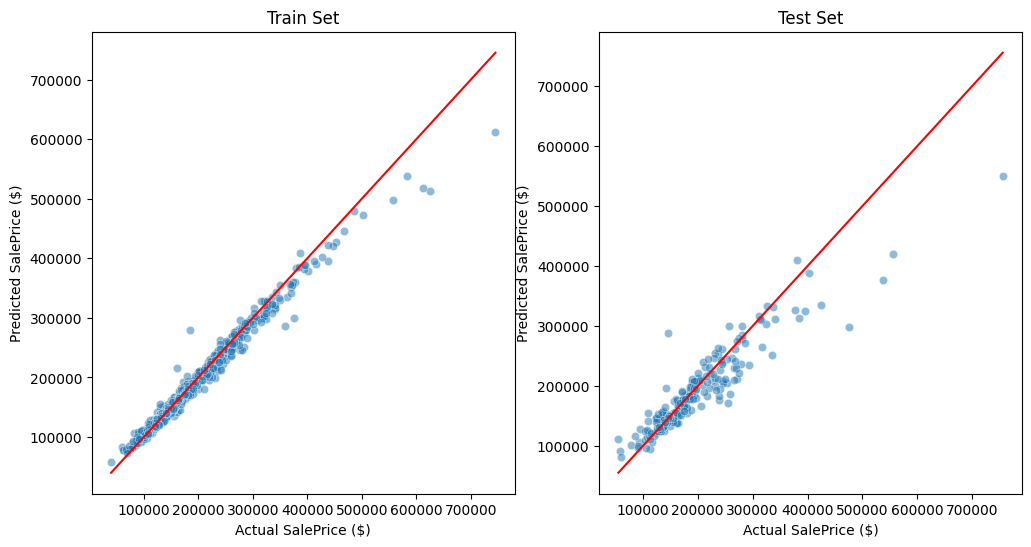

In [7]:
# Extract the best estimator from the GridSearchCV results
best_regressor_rf = search.best_estimator_

# Evaluate performance on both sets to ensure generalization
print("--- Optimized Random Forest Performance ---")
regression_performance(X_train, y_train, X_test, y_test, best_regressor_rf)
regression_evaluation_plots(X_train, y_train, X_test, y_test, best_regressor_rf)

## 6. Model Comparison

After evaluating our optimized Random Forest, we will now establish a baseline using a simpler model to verify if the added complexity provides a significant performance gain.



### 6.1 Baseline Model: Linear Regression

Linear Regression serves as our primary benchmark. It is a simple, fast, and interpretable model that assumes a linear relationship between the features and the target variable. We will train it and reverse the logarithmic transformation to get predictions in real dollars.

--- Linear Regression Performance ---
=== Model Evaluation ===

* Train Set
R2 Score: 0.76
Mean Absolute Error: 17498.123
Mean Squared Error: 1434272768.709
Root Mean Squared Error: 37871.794


* Test Set
R2 Score: 0.878
Mean Absolute Error: 18394.255
Mean Squared Error: 900778895.436
Root Mean Squared Error: 30012.979




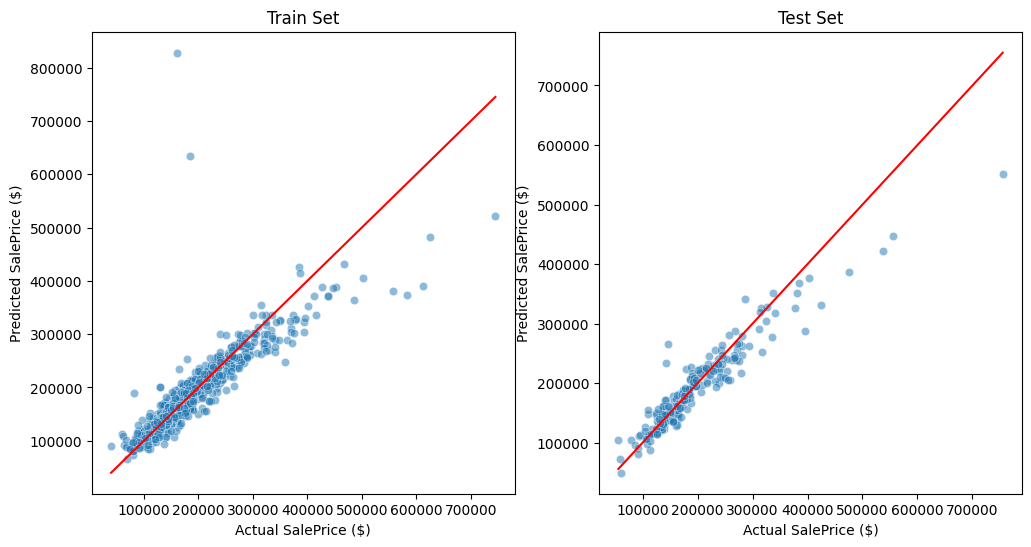

In [6]:
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Initialize pipeline with scaling and linear regression model
lin_reg_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

# Fit the model to the training data
lin_reg_pipe.fit(X_train, y_train)

# Performance evaluation using custom utility functions
print("--- Linear Regression Performance ---")
regression_performance(X_train, y_train, X_test, y_test, lin_reg_pipe)
regression_evaluation_plots(X_train, y_train, X_test, y_test, lin_reg_pipe)

### 6.2 Baseline Model: Decision Tree Regressor

We also include a standard Decision Tree. Since a Random Forest is an ensemble of many trees, comparing it against a single tree helps us quantify the exact accuracy gained by using the complex ensemble approach.

--- Decision Tree Performance ---
=== Model Evaluation ===

* Train Set
R2 Score: 1.0
Mean Absolute Error: 8.484
Mean Squared Error: 31821.866
Root Mean Squared Error: 178.387


* Test Set
R2 Score: 0.744
Mean Absolute Error: 26659.431
Mean Squared Error: 1890358106.891
Root Mean Squared Error: 43478.249




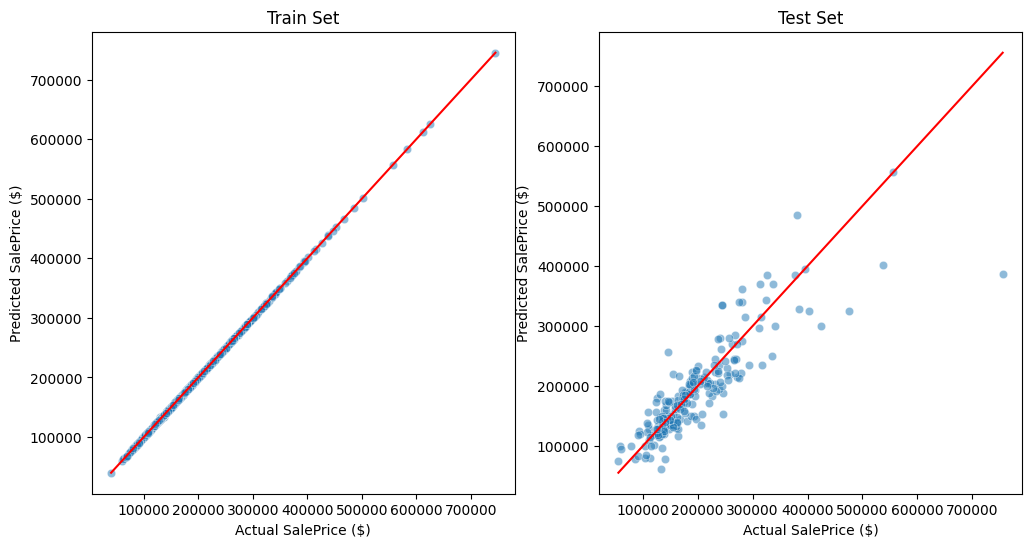

In [9]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Initialize pipeline with scaling and decision tree regressor
tree_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', DecisionTreeRegressor(random_state=101))
])

# Fit the model to the training data
tree_pipe.fit(X_train, y_train)

# Performance evaluation to check for potential overfitting
print("--- Decision Tree Performance ---")
regression_performance(X_train, y_train, X_test, y_test, tree_pipe)
regression_evaluation_plots(X_train, y_train, X_test, y_test, tree_pipe)

### 6.3 Model Comparison & Selection

Now we bring all predictions together to compare their performance on the Test Set. We will evaluate the models based on the R2 Score and the Mean Absolute Error (MAE) in real dollars to select the best engine for our dashboard.

In [11]:
import pandas as pd
import numpy as np
from sklearn.metrics import r2_score, mean_absolute_error

# 1. Reverse the logarithm for the actual test data
y_test_real = np.expm1(y_test)

# 2. Generate predictions using the trained models from previous sections
# and reverse the log (expm1) to get real Dollar values
pred_lin_real = np.expm1(lin_reg_pipe.predict(X_test))
pred_tree_real = np.expm1(tree_pipe.predict(X_test))
pred_rf_real = np.expm1(search.best_estimator_.predict(X_test))

# 3. Build the comparative DataFrame
comparison_df = pd.DataFrame({
    "Model": ["Linear Regression (Baseline)", "Random Forest (Optimized)", "Decision Tree"],
    "R2 Score": [
        r2_score(y_test_real, pred_lin_real),
        r2_score(y_test_real, pred_rf_real),
        r2_score(y_test_real, pred_tree_real)
    ],
    "MAE (Real $)": [
        mean_absolute_error(y_test_real, pred_lin_real),
        mean_absolute_error(y_test_real, pred_rf_real),
        mean_absolute_error(y_test_real, pred_tree_real)
    ]
})

# 4. Sort the DataFrame by R2 Score (Highest to Lowest) for better readability
comparison_df = comparison_df.sort_values(by="R2 Score", ascending=False).reset_index(drop=True)

# 5. Display the final verdict
print("--- Final Model Comparison (Test Set) ---")
display(comparison_df.round(3))

--- Final Model Comparison (Test Set) ---


,Model,R2 Score,MAE (Real $)
0,Linear Regression (Baseline),0.878,18394.255
1,Random Forest (Optimized),0.839,20007.565
2,Decision Tree,0.744,26659.431


### 6.4 (Bonus) Architectural Experiment: The Impact of Explicit Feature Selection

**Hypothesis:** Would applying explicit automated feature selection (`SelectFromModel`) to our primary algorithms improve their predictive performance, or would it discard valuable subtle variables from our already engineered dataset?

**Experiment:** We trained and evaluated two versions of our main algorithms (Linear Regression and Random Forest): one baseline version (No Selector) and one experimental version (With `SelectFromModel` acting as a strict hard filter). This allows for a direct apples-to-apples comparison of the architectural impact.

**Results:**
* **Linear Regression (Baseline / No Selector):** $R^2 = 0.878$ | MAE = $18,394
* **Linear Regression (With Selector):** $R^2 = 0.831$ | MAE = $21,936
* **Random Forest (Baseline / No Selector):** $R^2 \approx 0.839$ | MAE $\approx \$20,007$
* **Random Forest (With Selector):** $R^2 \approx 0.749$ | MAE $\approx \$27,014$

**Conclusion:** The experiment conclusively proved that forcing explicit feature selection *degraded* the performance of both the Linear Regression and the Random Forest models. Because rigorous feature selection and scaling were already performed manually during the Exploratory Data Analysis (EDA) phase, the input dataset was already highly optimized. 

The algorithms achieved their peak performance by utilizing all provided features and relying on their internal mathematical weighting to naturally handle the data. The `SelectFromModel` transformer acted too aggressively, discarding subtle variables that the algorithms were successfully using to fine-tune the `SalePrice` prediction. Therefore, the simpler, unfiltered pipelines remain the superior choice for production.

In [12]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import r2_score, mean_absolute_error

# 1. Linear Regression Architectures
lin_reg_baseline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

lin_reg_experimental = Pipeline([
    ('scaler', StandardScaler()),
    ('feat_selection', SelectFromModel(LinearRegression())),
    ('model', LinearRegression())
])

# 2. Random Forest Architectures (Base parameters for fast architectural comparison)
rf_baseline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestRegressor(random_state=101))
])

rf_experimental = Pipeline([
    ('scaler', StandardScaler()),
    ('feat_selection', SelectFromModel(RandomForestRegressor(random_state=101))),
    ('model', RandomForestRegressor(random_state=101))
])

# 3. Fit all pipelines
pipelines = {
    "Linear Regression (No Selector - Baseline)": lin_reg_baseline,
    "Linear Regression (With Selector)": lin_reg_experimental,
    "Random Forest (No Selector - Baseline)": rf_baseline,
    "Random Forest (With Selector)": rf_experimental
}

for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)

# 4. Generate Predictions and Reverse Logarithm
y_test_real = np.expm1(y_test)
results = []

for name, pipe in pipelines.items():
    pred_log = pipe.predict(X_test)
    pred_real = np.expm1(pred_log)
    
    r2 = r2_score(y_test_real, pred_real)
    mae = mean_absolute_error(y_test_real, pred_real)
    
    results.append({"Architecture": name, "R2 Score": r2, "MAE (Real $)": mae})

# 5. Construct and display the comparative DataFrame
experiment_results = pd.DataFrame(results)

print("--- Bonus Experiment Results: The Impact of Feature Selection ---")
display(experiment_results.round(3))

--- Bonus Experiment Results: The Impact of Feature Selection ---


,Architecture,R2 Score,MAE (Real $)
0,Linear Regression (No Selector - Baseline),0.878,18394.255
1,Linear Regression (With Selector),0.831,21936.791
2,Random Forest (No Selector - Baseline),0.839,21123.321
3,Random Forest (With Selector),0.784,27167.032


## 7. Save the Trained Model

As shown in the comparison above, the **Linear Regression** model unexpectedly outperformed the complex Random Forest, providing the highest R2 Score (0.878) and the lowest error margin (MAE). 

Following the principle of simplicity and efficiency, we will select the Linear Regression as our final model. We will serialize this pipeline and the training columns order to be used in our Streamlit application.

In [13]:
import joblib
import os

version = 'v1'
file_path = f'../outputs/ml_pipeline/predict_housing/{version}'
os.makedirs(file_path, exist_ok=True)

# Save the winning Linear Regression pipeline
joblib.dump(lin_reg_pipe, f'{file_path}/linear_regression_pipeline.pkl')

# Save the training columns to ensure identical ordering in the Streamlit app
joblib.dump(X_train.columns.to_list(), f'{file_path}/train_columns.pkl')

print(f"✅ Success! Winning model and feature columns saved to: {file_path}/")

✅ Success! Winning model and feature columns saved to: ../outputs/ml_pipeline/predict_housing/v1/


## 8. Generate and Save Performance Plots

To present our findings in the Streamlit dashboard effectively, we will generate and save static images of our model's evaluation plots and feature importance (coefficients). 

**Why save images instead of rendering live?**
* **Performance:** Rendering complex scatter plots on the fly consumes significant server memory and slows down the web application.
* **Consistency & MLOps Best Practices:** Saving the exact plot generated during the training phase guarantees reproducibility and prevents any discrepancies or data leakage during deployment.

/tmp/ipykernel_16912/1512379133.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=importance_df, palette='viridis')


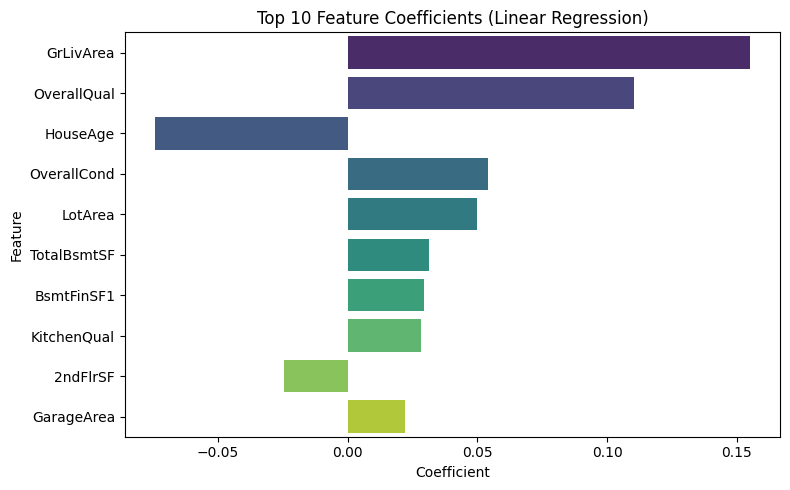

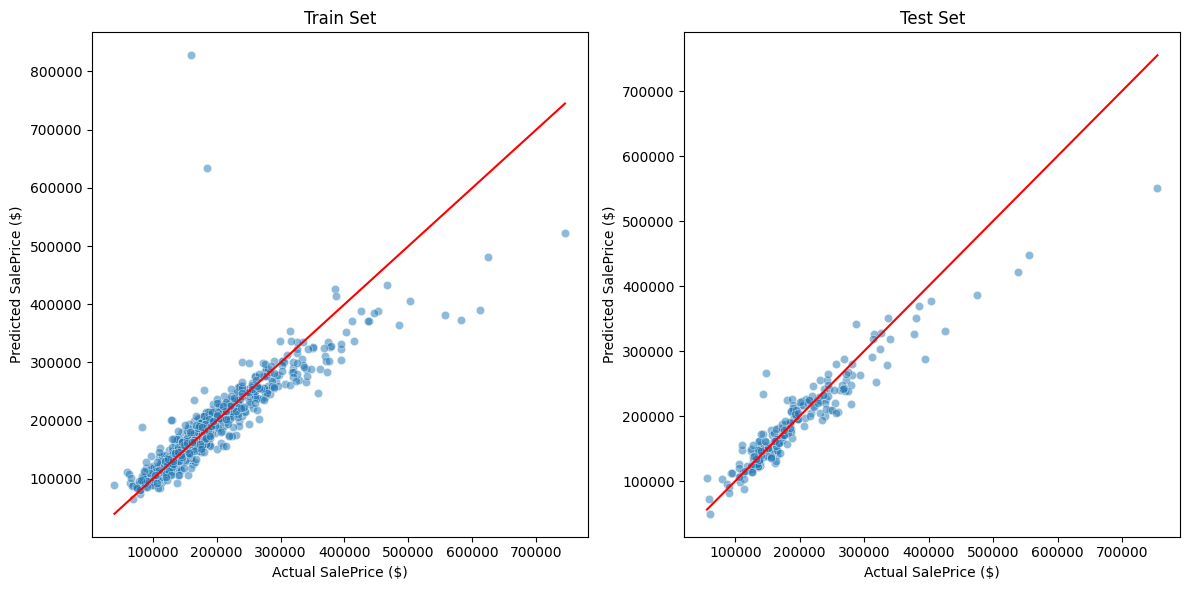

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

version = 'v1'
file_path = f'../outputs/ml_pipeline/predict_housing/{version}'

# 1. Coefficient Plot (Linear Regression Feature Importance)
model = lin_reg_pipe.named_steps['model']
importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': model.coef_
}).sort_values(by='Coefficient', key=abs, ascending=False).head(10)

plt.figure(figsize=(8, 5))
sns.barplot(x='Coefficient', y='Feature', data=importance_df, palette='viridis')
plt.title('Top 10 Feature Coefficients (Linear Regression)')
plt.tight_layout()
plt.savefig(f'{file_path}/feature_importance.png')
plt.show()

# 2. Evaluation Plots (Actual vs Predicted)
pred_train = lin_reg_pipe.predict(X_train)
pred_test = lin_reg_pipe.predict(X_test)

# Reversing log transformation for realistic dollar values
y_train_real = np.expm1(y_train)
pred_train_real = np.expm1(pred_train)
y_test_real = np.expm1(y_test)
pred_test_real = np.expm1(pred_test)

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12,6))
sns.scatterplot(x=y_train_real, y=pred_train_real, alpha=0.5, ax=axes[0])
sns.lineplot(x=y_train_real, y=y_train_real, color='red', ax=axes[0])
axes[0].set_xlabel("Actual SalePrice ($)")
axes[0].set_ylabel("Predicted SalePrice ($)")
axes[0].set_title("Train Set")

sns.scatterplot(x=y_test_real, y=pred_test_real, alpha=0.5, ax=axes[1])
sns.lineplot(x=y_test_real, y=y_test_real, color='red', ax=axes[1])
axes[1].set_xlabel("Actual SalePrice ($)")
axes[1].set_ylabel("Predicted SalePrice ($)")
axes[1].set_title("Test Set")

plt.tight_layout()
plt.savefig(f'{file_path}/regression_evaluation_plots.png')
plt.show()
